In [47]:
import numpy as np
from pathlib import Path

# Choose the parent folder and run name.
# Expected layout for this experiment:
# exp_data/max_grad_norm/1.0/seed5/cifar10_half_cnn_eps2.0/losses_in.npy
# exp_data/max_grad_norm/1.0/seed6/cifar10_half_cnn_eps2.0/losses_out.npy
results_root = Path("exp_data/max_grad_norm/1.0")
run_name = "cifar10_half_cnn_eps2.0"
seeds = [5,6,7,8,9]

all_losses_in = []
all_losses_out = []
emp_losses = []

for seed in seeds:
    base = results_root / f"seed{seed}" / run_name
    in_path = base / "losses_in.npy"
    out_path = base / "losses_out.npy"

    if not in_path.exists() or not out_path.exists():
        raise FileNotFoundError(f"Missing losses for seed {seed}: {base}")

    seed_losses_in = np.load(in_path).reshape(-1)
    seed_losses_out = np.load(out_path).reshape(-1)

    print(f"seed {seed}: losses_in {seed_losses_in.shape}, losses_out {seed_losses_out.shape}")

    all_losses_in.append(seed_losses_in)
    all_losses_out.append(seed_losses_out)
    emp_losses.append(np.mean(np.concatenate([seed_losses_in, seed_losses_out])))

losses_in = np.concatenate(all_losses_in)
losses_out = np.concatenate(all_losses_out)

print("\nConcatenated across seeds 5-9")
print("losses_in:", losses_in.shape, losses_in.dtype)
print("losses_out:", losses_out.shape, losses_out.dtype)
print("mean empirical loss across the five seeds:", float(np.mean(emp_losses)))
print(losses_in)
print(losses_out)

seed 5: losses_in (100,), losses_out (100,)
seed 6: losses_in (100,), losses_out (100,)
seed 7: losses_in (100,), losses_out (100,)
seed 8: losses_in (100,), losses_out (100,)
seed 9: losses_in (100,), losses_out (100,)

Concatenated across seeds 5-9
losses_in: (500,) float64
losses_out: (500,) float64
mean empirical loss across the five seeds: -5.793532562851905
[-6.58754015 -8.18331814 -6.59491396 -7.10351562 -7.03113317 -5.69584846
 -6.15520239 -5.49449348 -5.77564478 -7.62563276 -5.11787748 -7.17541504
 -4.3843441  -6.15557003 -6.93572426 -7.87129116 -7.7116766  -5.29892063
 -5.45697212 -4.63691902 -7.34587812 -3.22857189 -7.58277607 -6.88469744
 -5.24616289 -6.15069246 -3.68253827 -5.59923697 -7.39948273 -7.77665281
 -5.21402884 -6.48097181 -6.47802305 -4.79314041 -4.53118181 -8.46925545
 -7.56920815 -6.86877012 -7.81023026 -6.59770203 -6.72559643 -8.46512127
 -6.94296932 -7.73461771 -6.54601288 -4.54303741 -6.32967901 -4.68229818
 -5.84985495 -6.33932924 -6.61271143 -6.84363699 -

losses_in_clean: (500,)
losses_out_clean: (500,)


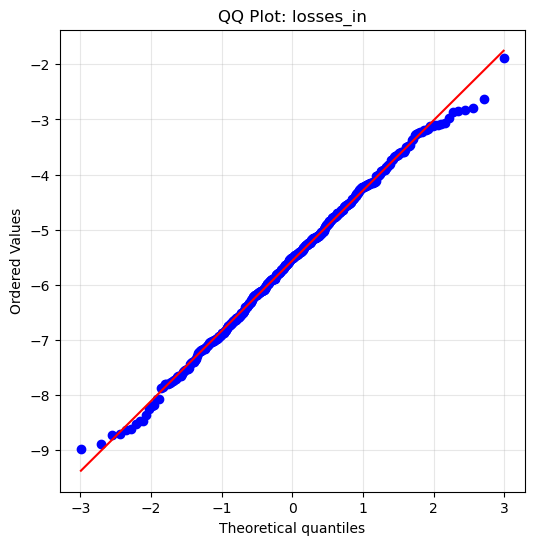

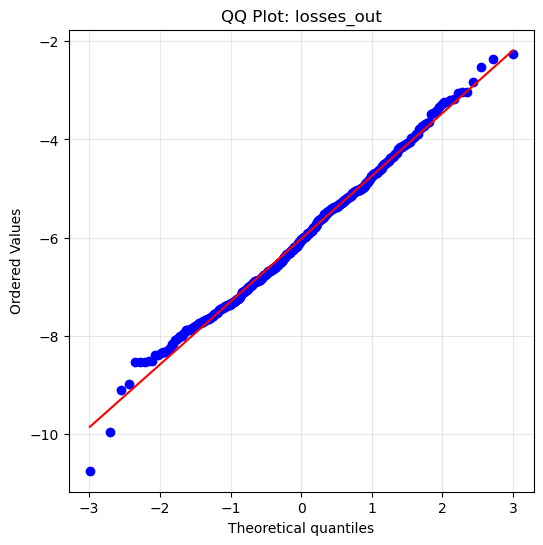

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Optional: remove non-finite values just in case
losses_in_clean = losses_in #[np.isfinite(losses_in)]
losses_out_clean = losses_out# [np.isfinite(losses_out)]

print("losses_in_clean:", losses_in_clean.shape)
print("losses_out_clean:", losses_out_clean.shape)

# QQ plot for losses_in
plt.figure(figsize=(6, 6))
stats.probplot(losses_in_clean, dist="norm", plot=plt)
plt.title("QQ Plot: losses_in")
plt.grid(True, alpha=0.3)
plt.show()

# QQ plot for losses_out
plt.figure(figsize=(6, 6))
stats.probplot(losses_out_clean, dist="norm", plot=plt)
plt.title("QQ Plot: losses_out")
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
import numpy as np
from scipy.stats import shapiro

# Clean in case there are NaN or inf values
# losses_in_clean = losses_in[np.isfinite(losses_in)]
# losses_out_clean = losses_out[np.isfinite(losses_out)]

# Shapiro-Wilk tests
shapiro_in = shapiro(losses_in_clean)
shapiro_out = shapiro(losses_out_clean)

print("Shapiro-Wilk test for losses_in")
print(f"  W statistic: {shapiro_in.statistic:.6f}")
print(f"  p-value:     {shapiro_in.pvalue:.6e}")

print("\nShapiro-Wilk test for losses_out")
print(f"  W statistic: {shapiro_out.statistic:.6f}")
print(f"  p-value:     {shapiro_out.pvalue:.6e}")

alpha = 0.05

print("\nInterpretation at alpha = 0.05:")
if shapiro_in.pvalue > alpha:
    print("  losses_in: fail to reject normality")
else:
    print("  losses_in: reject normality")

if shapiro_out.pvalue > alpha:
    print("  losses_out: fail to reject normality")
else:
    print("  losses_out: reject normality")

Shapiro-Wilk test for losses_in
  W statistic: 0.996795
  p-value:     4.282190e-01

Shapiro-Wilk test for losses_out
  W statistic: 0.995035
  p-value:     1.087880e-01

Interpretation at alpha = 0.05:
  losses_in: fail to reject normality
  losses_out: fail to reject normality


In [50]:
import numpy as np
from scipy.stats import anderson

alpha_pct = 5.0

def report_anderson(sample, label, alpha_pct=5.0):
    result = anderson(sample, dist="norm")
    sig_levels = np.array(result.significance_level, dtype=float)
    crit_values = np.array(result.critical_values, dtype=float)
    idx = int(np.argmin(np.abs(sig_levels - alpha_pct)))

    print(f"Anderson-Darling test for {label}")
    print(f"  A^2 statistic:  {result.statistic:.6f}")
    print("  Critical values:")
    for level, critical in zip(sig_levels, crit_values):
        print(f"    {level:>4.1f}%: {critical:.6f}")

    chosen_level = sig_levels[idx]
    chosen_critical = crit_values[idx]
    print(f"  Interpretation at {chosen_level:.1f}%:")
    if result.statistic < chosen_critical:
        print("    fail to reject normality")
    else:
        print("    reject normality")
    print()

report_anderson(losses_in_clean, "losses_in", alpha_pct=alpha_pct)
report_anderson(losses_out_clean, "losses_out", alpha_pct=alpha_pct)

Anderson-Darling test for losses_in
  A^2 statistic:  0.244597
  Critical values:
    15.0%: 0.571000
    10.0%: 0.651000
     5.0%: 0.781000
     2.5%: 0.911000
     1.0%: 1.083000
  Interpretation at 5.0%:
    fail to reject normality

Anderson-Darling test for losses_out
  A^2 statistic:  0.635895
  Critical values:
    15.0%: 0.571000
    10.0%: 0.651000
     5.0%: 0.781000
     2.5%: 0.911000
     1.0%: 1.083000
  Interpretation at 5.0%:
    fail to reject normality



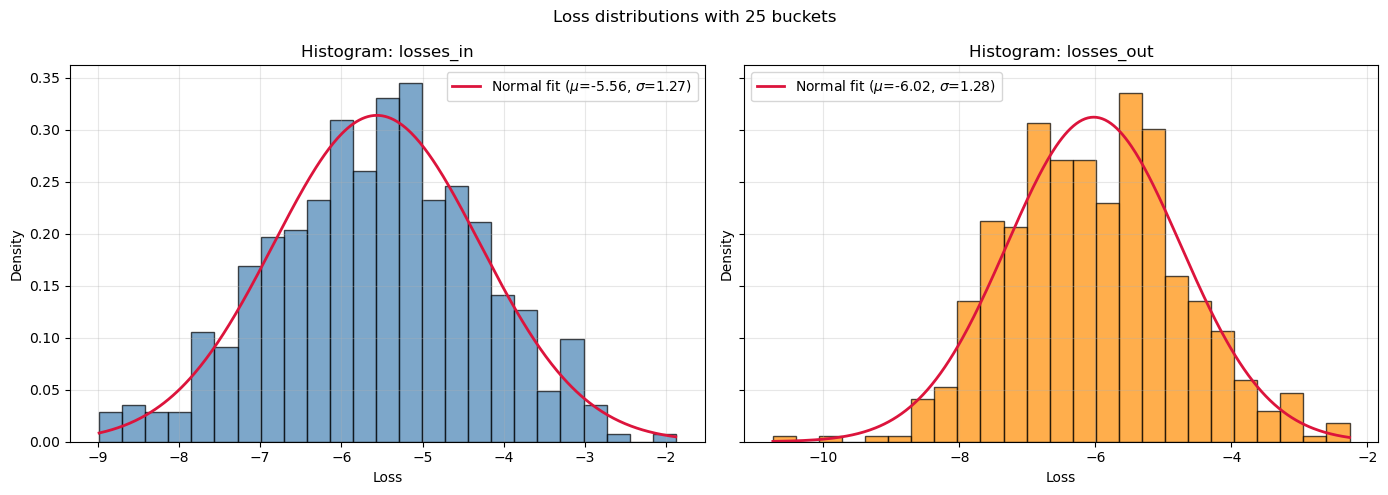

In [51]:
import matplotlib.pyplot as plt
from scipy.stats import norm

bucket_count = 25

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, data, title, color in [
    (axes[0], losses_in_clean, "Histogram: losses_in", "steelblue"),
    (axes[1], losses_out_clean, "Histogram: losses_out", "darkorange"),
]:
    mu = np.mean(data)
    sigma = np.std(data, ddof=1)
    bins = np.linspace(np.min(data), np.max(data), bucket_count + 1)

    ax.hist(data, bins=bins, density=True, alpha=0.7, color=color, edgecolor="black")

    x = np.linspace(np.min(data), np.max(data), 400)
    ax.plot(x, norm.pdf(x, mu, sigma), color="crimson", linewidth=2,
            label=f"Normal fit ($\\mu$={mu:.2f}, $\\sigma$={sigma:.2f})")

    ax.set_title(title)
    ax.set_xlabel("Loss")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(f"Loss distributions with {bucket_count} buckets")
plt.tight_layout()
plt.show()